# How to encode, recognize and compare simple formal languages?

<div style="line-height:0.3;">
<b>Author</b>: Louis de Lavenne

<b>Date</b>: May 2026
</div>

**Important note**: This project was partly achieved with the help of a LLM: it verified that there (almost?) wasn't any mistake.

#
---
---
## 1. Question
---

### 1.1. <u>Motivation

As our ability to infer general linguistic rules from a very small amount of examples still seems mysterious, it may be relevant to formalize and automate the abilities it seems to demand: $(i)$ first, encoding — the ability to generate a language given its rules, and $(ii)$ second, recognizing — the ability to find which rules generated a set of words. It is probably not exactly how it actually cognitively works, in our human minds. Yet, it would still be a first model.

Implicit rules may be present in any field of linguistics (phonology, semantics…), buy as a very first step, let's focus on syntactic rules, with formal languages, and more specifically, regular languages — which are indeed the simpliest level of the Chomsky hierarchy.

#
### 1.2. <u>Question

---
---

### $$How to encode, recognize and compare regular languages?$$

---
---

#
### 1.3. <u>Definitions, notations and</u> `python` <u>encoding

As some specific vocabulary will be used across this project, let's explain them at first (if needed, to go back to check it afterwards)

1. $ALPHABET$ – _noted_ $A$ or $A_k$, for $k \in \N^*$: a set of characters ($i.e.$, here, letters) – noted $c$ or $c_\kappa$ or $c_{\kappa_i}$, $i \in \N^*$. It will each time be explicitly defined as $A_k = \{c_1, …, c_\omega\}$ — $c_1, …, c_\omega$ being the $\omega \in \N$ characters of the alphabet.

    $\Rightarrow$ Encoding: a `list` of letters, with letters as `str`.

---

2. $STRING$ – noted $s$: a list of characters from an alphabet.

    $\Rightarrow$ Encoding: a `str`.

---

3. $RULE$ (abbreviation for grammatical rule) – _noted_ $R_l$ or $R_l(s)$ or $R_l(s, …)$, for $l \in \N^*$: explicit assertion of which scheme the string must correspond to, in order to respect the rule $R_l$.
For each language $L_k$, by default, the two first rules will be:
    1. $R_1$ or $R_1(s)$ or $R_1(s, n)$: the length of the string must be inferior or equal to some $n \in \N$; $i.e. \exists m \leqslant n, s \in A^m$, for some alphabet $A$.
    2. $R_2$ or $R_2(s)$ or $R_2(s, A_k)$: each letter of the string must be included in the corresponding alphabet $A_k$; $i.e. \exists m \in \N, s \in A_k^m$.

    $\Rightarrow$ Encoding: a `function` including `for` loops, `if` tests.

---

4. $LANGUAGE$ ($abbr.$ for formal language) – _noted_ $L_k$, for $k \in \N^*$: the set of strings which are generated by the alphabet $A_k$ and the conjunction of rules associated to $L_k$ – noted $R_{L_k}$.

    $(i)$ Noting $\lambda$ the number of rules of $L_k$, $(ii)$ For any $i \in \llbracket 1 \lambda \rrbracket$, noting $R_{L_k, i}$ the $i^{th}$ rule of $L_k$, and $(iii)$ Defining $R_{L_k, i \in \llbracket 3, \lambda \rrbracket}:= \displaystyle\bigwedge_{i \in \llbracket 3, \lambda \rrbracket} R_{L_k, i}$, we have:
    
    $R_{L_k} := R_{L_k, i \in \llbracket 1, \lambda \rrbracket} := R_1 \land R_2 \land R_{L_k, 3 \leqslant i \leqslant \lambda}$.

    <u>Note</u>: actually, for $\lambda = 2$, $L_k := \{s: R_1(s, n) \land R_2(s, A_k) \}$ is already a language.

    $\Rightarrow$ Encoding: a `list` of words, with words as `str`; a `function`.

---

5.  $PRESCRIPTIVE$ or $TESTING$ rule: the rule which verifies if a given string respects it.

    $\Rightarrow$ Encoding: a `function` returning the `bool` value of the testing rule applied to a given string.

    $//$ Antonym: $GENERATIVE$ rule: the rule which generates all the strings which respect it.

    $\Rightarrow$ Encoding: a `function` returning the `list` of all the strings which verify it.

    <u>Notes</u>:
    1. Each generative rule is associated to a testing rule; actually, test and generation are the two complementary sides of each rule.
    2. In practice, in `python`, in order to have finite algorithms, generative $R_1$ and $R_2$ will be a same `function`, although they are theoretically different.

---

6. $MAXIMUM$ string (in relation to a given $L_k$): a string $s_i := (c_{\kappa_1}, …, c_{\kappa_i}) \in A_k^m \cap L_k$, for $m \leqslant n$, which verifies:

    $\forall c_\kappa \in A_k [ s_{i+1} = (c_{\kappa_1}, …, c_{\kappa_i}, c_\kappa) \in A_k^{m+1} \land s_{i+1} \notin L_k ]$

    $\Rightarrow$ $MAXIMUM$ language (in relation to a given $L_k$) – noted $max(L_k)$: the set of maximum strings of $L_k$.

#
### 1.4. <u>Explicit goals and structure

1. $Goal 1$: creating formal languages

    1. $Goal 1.1$: defining the prescriptive rules
    2. $Goal 1.2$: defining the generative rules (corresponding to the former prescriptive ones)
    3. $Goal 1.3$: generating all the possible words of each language

2. $Goal 2$: comparing formal languages complexity — a first insight of how rules shape the structure of a language

#
---
---
## 2. Data — $Goal 1$
---

We are going to create our own database, of several rules and languages.

For $R_1$, in this section, we will always choose $n = 10$, in order not to have too big sets.

In [472]:
n = 10

### 2.1. <u>Prescriptive rules</u> — $Goal 1.1$

First, let's define the prescriptive rules, since they are easier to implement, and it is more logical to define them before the generative rules, which will indeed rely on them.

#### 2.1.1. _Mathematical definitions_

<u>Reminder — Default rules</u>:

1. $R_1(s, n) := [ \exists m \leqslant n, s \in A^m ]$, for some alphabet $A$.

    _Meaning_: the length of the string must be inferior or equal to some $n \in \N$.

2. $R_2(s, A_k) := [ \exists m \in \N, s \in A_k^m ]$

    _Meaning_: each letter of the string must be included in the corresponding alphabet $A_k$.

---

<u>Other possible rules</u>:

Consider an alphabet $A \supset \{c_{\kappa_1}, …, c_{\kappa_i}\}$, and $i \in \N^*$, and thus $s := (c_{\kappa_1}, …, c_{\kappa_i}) \in A^i$.

3. $R_3(s) := [ s: \forall j \in \llbracket 1, i-1 \rrbracket [ c_{\kappa_j} = b \Rightarrow c_{\kappa_{j+1}} ≠ b ] ]$

    _Meaning_: there cannot be two $b$ next to each other.

4. $R_4(s) := [ s: \forall j \in \llbracket 1, i \rrbracket [ (c_{\kappa_j} = b) \Rightarrow (j > 2 \land c_{\kappa_{j-1}} = c_{\kappa_{j-2}} ≠ b) ] ]$

    _Meaning_: each $b$ must be preceded by at least two same characters which are not $b$.

#### 2.1.2. `python` _definitions_

$(i)$ Rule $R_1$

In [473]:
def test_r_1(string, n):
    if len(string) > n:
        return False
    return True

$(ii)$ Rule $R_2$

In [474]:
def test_r_2(string, a_k):
    for symbol in string:
        if symbol not in a_k:
            return False
    return True

$(iii)$ Rule $R_3$

In [475]:
def test_r_3(string):
    if 'bb' in string:
        return False
    return True

$(iv)$ Rule $R_4$

In [476]:
def test_r_4(string):
    if 'b' in string:
        if 'bb' in string:
            return False        # in order to shorten the test if the case is obvious
        for i, c in enumerate(string):
# enumerate(string) gives the index of each character of string, and the character itself, in a pair
            if c == 'b' and string[i-1] != string[i-2]:
                return False
            if not 'b' in string[i+1:]:
                break
    return True

$(v)$ Conjunction of all rules of $L_k$ – $i.e.$, $R_{L_k}$

We assign a default value to the prescriptive $R_{L_k}$, that we will update too (adding it other tests), when necessary.

In `python`, we give it the following name: `all_tests_R_L_k`

In [477]:
def test_r_l_k(string, a_k, n, all_tests_r_l_k):
    # note: all_tests_r_l_k[0:2] = [test_r_1, test_r_2]
    if not all_tests_r_l_k[0](string, a_k) or not all_tests_r_l_k[1](string, n):
        return False
    for test in all_tests_r_l_k[2:]:          # if there are other tests than test_r_1 and test_r_2 in all_tests_r_l_k
        if not test(string):
            return False
    return True

$(v)(bis)$ Conjunction of all rules of $L_k$, except $R_1$ and $R_2$ – $i.e.$, $R_{L_k, i \in \llbracket 3, \lambda \rrbracket}$

This one will actually be more useful.

In `python`, to the prescriptive $R_{L_k, i \in \llbracket 3, \lambda \rrbracket}$, we give the following name: `all_tests_except_R_1_and_2`

In [478]:
def test_r_l_k_except_r_1_and_2(string, tests_r_l_k):
    for test in tests_r_l_k:
        if not test(string):
            return False
    return True             # (it works even if there is no other test than r_1 and r_2!)

### $\Rightarrow Goal 1.1$: Done $\checkmark$

### 2.1. <u>Generative rules</u> — $Goal 1.2$

Now, a little more complicated: the corresponding generative rules.

A generative rule encoding will always be a `function` including its recursively built associated language $L_k$ (recursion on itself or on a previous rule), and return the final language $L_k$, so following these steps:

1. Initialisation — at the step $i = 1$:

    1. $L_k \leftarrow A_k$

        _Meaning_: the language $L_k$ is at least composed of the alphabet $A_k$.

    2. $max(L_k) \leftarrow Ø$

        _Meaning_: for the moment, we don't know any of the maximum strings of $L_k$.

2. Recursion — at the step $i+1$, for $i \in \N$:

    1. $L_k \leftarrow L_k \cup \{s_{i+1} = (c_{\kappa_1}, …, c_{\kappa_j}, c_\kappa): [ j \in \llbracket 1, i \rrbracket ] \land [ s_i = (c_{\kappa_1}, …, c_{\kappa_j}) \in L_k ] \land [ s_i \notin max(L_k) ] \land [ c_\kappa \in A_k ] \land R_{L_k}(s)\}$

        or, in other terms, much simplier:
    
        $L_k \leftarrow L_k \cup \{s_{i+1} \in A_k^{i+1}: R_{L_k}(s)\}$

        _Meaning_: at the iteration $i+1$, we add the strings of $A_k^{i+1}$ which verify $R_{L_k}$ to the language $L_k$
    
    2. $max(L_k) \leftarrow max(L_k) \cup \{s_i = (c_{\kappa_1}, …, c_{\kappa_i}) \in L_k: \forall c_\kappa \in A_k [ s_{i+1} = (c_{\kappa_1}, …, c_{\kappa_i}, c_\kappa) \in A_k^{m+1} \land s_{i+1} \notin L_k ]\}$

        _Meaning_: at the iteration $i+1$, we add the maximum strings of $A_k^i$ to $max(L_k)$

$(i-ii)$ Rules $R_1$ and $R_2$

<u>Notes</u>:

1. We merge generative $R_1$ and $R_2$ into one single `function`, because in `python` they are the same.

    So, in the following function, $A = A_k$ and $L = L_k$.

2. No need for $max(L_k)$ yet, since here the only rules are $R_1$ and $R_2$: here, $max(L_k) = A_k^n$.

In [479]:
def gen_r_1_and_2(n, A):
    # Initialisation
    L = A.copy()
    # Recursion
    for former_string in L:                 # r_2
        if len(former_string) < n:          # r_1
            for character in A:             # r_2
                new_string = former_string + character
                L.append(new_string)
    return L

$(iii – iv -…)$ Rules $R_3$ and/or $R_4$ — and/or any rule which takes a string as single argument — $i.e.$, $R_{L_k}$

<u>Note</u>: once again, we merge generative $R_1$, $R_2$, and $R_3$ and/or $R_4$ into one single `function`.

But this time, it is more precisely because it is algorithmically much better to do so. Indeed, if we separated each generative rule, we would have to intersect each of their languages — so, having calculated any element which verifies one rule but doesn't verify another one would have been useless.

In [480]:
def gen_r_l_k(n, a_k, testing_rules):
    # Initialisation
    L_k = a_k.copy()
    L_k_max_strings = [] # the list of maximum strings
    # Recursion
    for former_string in L_k:                                                   # r_2
        if len(former_string) < n and former_string not in L_k_max_strings:     # r_1
            for character in a_k:                                               # r_2
                new_string = former_string + character
                if test_r_l_k_except_r_1_and_2(new_string, testing_rules):      # r_l_k without r_1 and r_2 (which are indeed already verified)
                    L_k.append(new_string)
                else:
                    L_k_max_strings.append(former_string)
    return L_k

### $\Rightarrow Goal 1.2$: Done $\checkmark$

### 2.2. <u>Generating languages</u> — $Goal 1.3$

#### 2.2.1. _General generation function, for any language_ $L_k$

We have actually already done it in the previous cells!

But for more clarity, let's give the following name:

In [481]:
def gen_language(n, a_k, testing_rules):
    return gen_r_l_k(n, a_k, testing_rules)

#### 2.2.2. _Applying the former function on particular language examples_

---
$(i)$ Language $L_1$

1. Alphabet: $A_1 := \{a\}$

2. Rules: $R_1$, $R_2$

3. Explicit language: $L_1 = \{s \in A_1^m: m \in \llbracket 1, n \rrbracket\}$

4. Explanation: this language generates only strings containing $a$ letters, their length varying from $1$ to $n$.

In [482]:
A_1 = ['a']
all_tests_except_R_1_and_2 = list()
L_1 = gen_language(n, A_1, all_tests_except_R_1_and_2)
print(len(L_1), L_1)

10 ['a', 'aa', 'aaa', 'aaaa', 'aaaaa', 'aaaaaa', 'aaaaaaa', 'aaaaaaaa', 'aaaaaaaaa', 'aaaaaaaaaa']


---
$(ii)$ Language $L_2$

1. Alphabet: $A_2 := \{a,b\}$

2. Rules: $R_1$, $R_2$

3. Explicit language: $L_2 = \{s \in A_2^m: m \in \llbracket 1, n \rrbracket\}$

4. Explanation: this language generates only strings containing $a$ and $b$ letters, their length varying from $1$ to $n$.

In [483]:
A_2 = ['a', 'b']
all_tests_except_R_1_and_2 = list()
L_2 = gen_language(n, A_2, all_tests_except_R_1_and_2)
print(len(L_2), L_2)

2046 ['a', 'b', 'aa', 'ab', 'ba', 'bb', 'aaa', 'aab', 'aba', 'abb', 'baa', 'bab', 'bba', 'bbb', 'aaaa', 'aaab', 'aaba', 'aabb', 'abaa', 'abab', 'abba', 'abbb', 'baaa', 'baab', 'baba', 'babb', 'bbaa', 'bbab', 'bbba', 'bbbb', 'aaaaa', 'aaaab', 'aaaba', 'aaabb', 'aabaa', 'aabab', 'aabba', 'aabbb', 'abaaa', 'abaab', 'ababa', 'ababb', 'abbaa', 'abbab', 'abbba', 'abbbb', 'baaaa', 'baaab', 'baaba', 'baabb', 'babaa', 'babab', 'babba', 'babbb', 'bbaaa', 'bbaab', 'bbaba', 'bbabb', 'bbbaa', 'bbbab', 'bbbba', 'bbbbb', 'aaaaaa', 'aaaaab', 'aaaaba', 'aaaabb', 'aaabaa', 'aaabab', 'aaabba', 'aaabbb', 'aabaaa', 'aabaab', 'aababa', 'aababb', 'aabbaa', 'aabbab', 'aabbba', 'aabbbb', 'abaaaa', 'abaaab', 'abaaba', 'abaabb', 'ababaa', 'ababab', 'ababba', 'ababbb', 'abbaaa', 'abbaab', 'abbaba', 'abbabb', 'abbbaa', 'abbbab', 'abbbba', 'abbbbb', 'baaaaa', 'baaaab', 'baaaba', 'baaabb', 'baabaa', 'baabab', 'baabba', 'baabbb', 'babaaa', 'babaab', 'bababa', 'bababb', 'babbaa', 'babbab', 'babbba', 'babbbb', 'bbaaaa'

---
$(iii)$ Language $L_3$

1. Alphabet: $A_3 := \{a,b\}$

2. Rules: $R_1$, $R_2$, $R_3$

3. Explicit language: $L_3 = \{s \in A_3^m: m \in \llbracket 1, n \rrbracket \land R_3(s)\}$

    _Reminder_: $R_3 := [ s: \forall j \in \llbracket 1, i-1 \rrbracket [ c_{\kappa_j} = b \Rightarrow c_{\kappa_{j+1}} ≠ b ] ]$

4. Explanation: this language generates only strings in which there cannot be two $b$ next to each other, their length varying from $1$ to $n$.

In [484]:
A_3 = ['a', 'b']
all_tests_except_R_1_and_2 = [test_r_3]
L_3 = gen_language(n, A_3, all_tests_except_R_1_and_2)
print(len(L_3), L_3)

374 ['a', 'b', 'aa', 'ab', 'ba', 'aaa', 'aab', 'aba', 'baa', 'bab', 'aaaa', 'aaab', 'aaba', 'abaa', 'abab', 'baaa', 'baab', 'baba', 'aaaaa', 'aaaab', 'aaaba', 'aabaa', 'aabab', 'abaaa', 'abaab', 'ababa', 'baaaa', 'baaab', 'baaba', 'babaa', 'babab', 'aaaaaa', 'aaaaab', 'aaaaba', 'aaabaa', 'aaabab', 'aabaaa', 'aabaab', 'aababa', 'abaaaa', 'abaaab', 'abaaba', 'ababaa', 'ababab', 'baaaaa', 'baaaab', 'baaaba', 'baabaa', 'baabab', 'babaaa', 'babaab', 'bababa', 'aaaaaaa', 'aaaaaab', 'aaaaaba', 'aaaabaa', 'aaaabab', 'aaabaaa', 'aaabaab', 'aaababa', 'aabaaaa', 'aabaaab', 'aabaaba', 'aababaa', 'aababab', 'abaaaaa', 'abaaaab', 'abaaaba', 'abaabaa', 'abaabab', 'ababaaa', 'ababaab', 'abababa', 'baaaaaa', 'baaaaab', 'baaaaba', 'baaabaa', 'baaabab', 'baabaaa', 'baabaab', 'baababa', 'babaaaa', 'babaaab', 'babaaba', 'bababaa', 'bababab', 'aaaaaaaa', 'aaaaaaab', 'aaaaaaba', 'aaaaabaa', 'aaaaabab', 'aaaabaaa', 'aaaabaab', 'aaaababa', 'aaabaaaa', 'aaabaaab', 'aaabaaba', 'aaababaa', 'aaababab', 'aabaaaaa',

---

$(iv)$ Language $L_4$

1. Alphabet: $A_4 := \{a,b\}$

2. Rules: $R_1$, $R_2$, $R_4$

3. Explicit language: $L_4 = \{s: R_1(s, n), R_2(s, A_4), R_4(s)\}$

    _Reminder_: $R_4(s) := [ s: \forall j \in \llbracket 1, i \rrbracket [ (c_{\kappa_j} = b) \Rightarrow (j > 2 \land c_{\kappa_{j-1}} = c_{\kappa_{j-2}} ≠ b) ] ]$

4. Explanation: this language generates only strings in which each $b$ must be preceded by at least two same characters which are not $b$, their length varying from $1$ to $n$.

In [485]:
A_4 = ['a', 'b']
all_tests_except_R_1_and_2 = [test_r_4]
L_4 = gen_language(n, A_4, all_tests_except_R_1_and_2)
print(len(L_4), L_4)

87 ['a', 'b', 'aa', 'aaa', 'aab', 'aaaa', 'aaab', 'aaba', 'aaaaa', 'aaaab', 'aaaba', 'aabaa', 'aaaaaa', 'aaaaab', 'aaaaba', 'aaabaa', 'aabaaa', 'aabaab', 'aaaaaaa', 'aaaaaab', 'aaaaaba', 'aaaabaa', 'aaabaaa', 'aaabaab', 'aabaaaa', 'aabaaab', 'aabaaba', 'aaaaaaaa', 'aaaaaaab', 'aaaaaaba', 'aaaaabaa', 'aaaabaaa', 'aaaabaab', 'aaabaaaa', 'aaabaaab', 'aaabaaba', 'aabaaaaa', 'aabaaaab', 'aabaaaba', 'aabaabaa', 'aaaaaaaaa', 'aaaaaaaab', 'aaaaaaaba', 'aaaaaabaa', 'aaaaabaaa', 'aaaaabaab', 'aaaabaaaa', 'aaaabaaab', 'aaaabaaba', 'aaabaaaaa', 'aaabaaaab', 'aaabaaaba', 'aaabaabaa', 'aabaaaaaa', 'aabaaaaab', 'aabaaaaba', 'aabaaabaa', 'aabaabaaa', 'aabaabaab', 'aaaaaaaaaa', 'aaaaaaaaab', 'aaaaaaaaba', 'aaaaaaabaa', 'aaaaaabaaa', 'aaaaaabaab', 'aaaaabaaaa', 'aaaaabaaab', 'aaaaabaaba', 'aaaabaaaaa', 'aaaabaaaab', 'aaaabaaaba', 'aaaabaabaa', 'aaabaaaaaa', 'aaabaaaaab', 'aaabaaaaba', 'aaabaaabaa', 'aaabaabaaa', 'aaabaabaab', 'aabaaaaaaa', 'aabaaaaaab', 'aabaaaaaba', 'aabaaaabaa', 'aabaaabaaa', 'aabaaab

### $\Rightarrow Goal 1.3$: Done $\checkmark$

---

## $\Rightarrow Goal 1$: Done $\checkmark$

#
---
---
## 3. Analysis — $Goal 2$
---

### <u>Visualizing and comparing the algorithmic complexity of each language

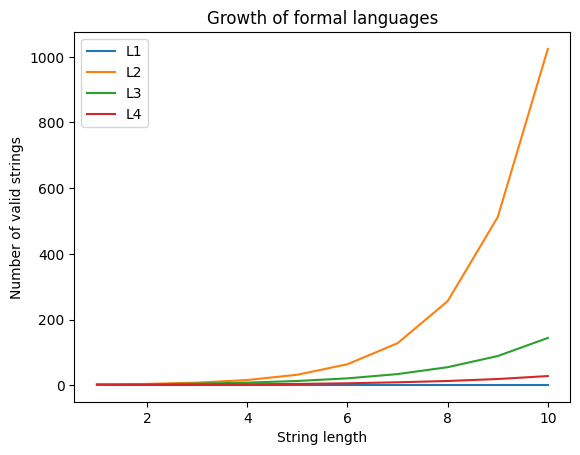

In [ ]:
import matplotlib.pyplot as plt

lengths = range(1, n + 1)

for language, label in [
    (L_1, "L1"),
    (L_2, "L2"),
    (L_3, "L3"),
    (L_4, "L4")
]:
    counts = [
        sum(len(s) == m for s in language)
        for m in lengths                        # for each length m, count how many strings in the language have that length
    ]

    plt.plot(lengths, counts, label=label)

plt.xlabel("String length")
plt.ylabel("Number of valid strings")
plt.title("Growth of formal languages")
plt.legend()
plt.show()

Although all four languages are generated from very small alphabets, their growth patterns differ significantly. The plot illustrates the fact that the complexity of a language is determined not only by the size of its alphabet but also by the constraints imposed on the combinations of characters. It is a first model of how impactful these simple rules can be.

## $\Rightarrow Goal 2$: Done $\checkmark$

#
---
---
## 4. Conclusion
---

This project explored a simple way to encode formal languages through explicit rules and to generate the corresponding sets of strings automatically.


Several languages were defined from different combinations of rules and alphabets. Once these rules were encoded in Python, it became possible both to generate the languages and to test whether a given string belonged to them.


The experiment shows that the structure of a language can be encoded by a small number of explicit rules. Once these rules are formalized, the corresponding set of valid expressions can be generated and recognized automatically.


One big limitation of this project is that the rules were assumed to be known in advance. A natural continuation would be to investigate whether such rules could be inferred automatically from observed strings only. This would move from language generation and recognition toward the broader problem of learning linguistic structure from data.


More generally, this project suggests that a potentially large set of expressions can be described by a relatively small number of explicit formal constraints, which is one of the central ideas of formal linguistics.